## Анализ факторов, влияющих на уровень счастья стран мира

### Краткое описание датасета

Данные взяты из World Happiness Report 2023. Набор содержит показатели уровня счастья по странам, а также оценку вклада экономических, социальных, демографических и институциональных факторов, основанных на опросе Gallup World Poll.

### Данные:

https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2023?resource=download


### Описание переменных:


- Country name	(категориальная) Название страны.

- Ladder score	(количественная, float)	Основной показатель счастья (оценка жизни по лестнице Канитрила), среднее значение по стране.

- Standard error of ladder score	(количественная)	Стандартная ошибка средней оценки счастья.

- upperwhisker	(количественная)	Верхняя граница 95% доверительного интервала для Ladder score.

- lowerwhisker	(количественная)	Нижняя граница 95% доверительного интервала.

- Logged GDP per capita	(количественная)	Логарифм ВВП на душу населения — показатель экономического развития.

- Social support	(количественная)	Доля людей, у которых есть близкие, способные помочь (социальная поддержка).

- Healthy life expectancy	(количественная)	Ожидаемая продолжительность здоровой жизни (в годах).

- Freedom to make life choices	(количественная)	Ощущение свободы выбора в повседневной жизни.

- Generosity	(количественная)	Склонность к благотворительности, пожертвованиям.

- Perceptions of corruption	(количественная)	Уровень доверия к государству, восприятие коррупции (выше → больше коррупции).

- Ladder score in Dystopia	(количественная)	Базовый уровень счастья в гипотетической стране с минимальными показателями по всем факторам.

- Explained by: Log GDP per capita	(количественная)	Вклад ВВП в оценку счастья (в процентах/баллах).

- Explained by: Social support	(количественная)	Вклад социальной поддержки в счастье.

- Explained by: Healthy life expectancy	(количественная)	Вклад здоровья.

- Explained by: Freedom to make life choices	(количественная)	Вклад свободы выбора.

- Explained by: Generosity	(количественная)	Вклад щедрости.

- Explained by: Perceptions of corruption	(количественная)	Вклад восприятия коррупции.

- Dystopia + residual	(количественная)	Остатки модели + базовый уровень — сколько не объясняется факторами.

### Задание 1

Сформулировать содержательно задачу исследования. Выбрать целевую переменную. Построить полиномиальную регрессию. Определить степень полинома с максимальным коэффициентом детерминации. Показать, достигнут результат за счет переобучения модели и нет. Выбрать оптимальную степень полинома или показать нецелесообразность построения полиномиальной регрессии

#### Задача исследования

Цель исследования- проверить, улучшает ли использование полиномиальной регрессии аппроксимацию зависимости между уровнем счастья стран мира и ключевыми социально-экономическими факторами по сравнению с линейной моделью, и не достигается ли рост качества модели за счёт переобучения.

#### Зависимая переменная (Y):
- Ladder score — средняя оценка удовлетворённости жизнью (уровень счастья).

#### Независимые переменные (X):
- Logged GDP per capita: Экономическое благосостояние страны.

- Social support: Социальный капитал и поддержка ближнего окружения.

- Healthy life expectancy: Продолжительность жизни.

- Freedom to make life choices: Свобода принятия решений.

- Perceptions of corruption: Восприятие уровня коррупции.

- Generosity: Уровень альтруизма и благотворительности.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df =pd.read_csv('data/WHR2023.csv')
df

,Country name,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,7.804,0.036,7.875,7.733,10.792,0.969,71.150,0.961,-0.019,0.182,1.778,1.888,1.585,0.535,0.772,0.126,0.535,2.363
1,Denmark,7.586,0.041,7.667,7.506,10.962,0.954,71.250,0.934,0.134,0.196,1.778,1.949,1.548,0.537,0.734,0.208,0.525,2.084
2,Iceland,7.530,0.049,7.625,7.434,10.896,0.983,72.050,0.936,0.211,0.668,1.778,1.926,1.620,0.559,0.738,0.250,0.187,2.250
3,Israel,7.473,0.032,7.535,7.411,10.639,0.943,72.697,0.809,-0.023,0.708,1.778,1.833,1.521,0.577,0.569,0.124,0.158,2.691
4,Netherlands,7.403,0.029,7.460,7.346,10.942,0.930,71.550,0.887,0.213,0.379,1.778,1.942,1.488,0.545,0.672,0.251,0.394,2.110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,Congo (Kinshasa),3.207,0.095,3.394,3.020,7.007,0.652,55.375,0.664,0.086,0.834,1.778,0.531,0.784,0.105,0.375,0.183,0.068,1.162
133,Zimbabwe,3.204,0.061,3.323,3.084,7.641,0.690,54.050,0.654,-0.046,0.766,1.778,0.758,0.881,0.069,0.363,0.112,0.117,0.905
134,Sierra Leone,3.138,0.082,3.299,2.976,7.394,0.555,54.900,0.660,0.105,0.858,1.778,0.670,0.540,0.092,0.371,0.193,0.051,1.221
135,Lebanon,2.392,0.044,2.479,2.305,9.478,0.530,66.149,0.474,-0.141,0.891,1.778,1.417,0.476,0.398,0.123,0.061,0.027,-0.110


оставим только те столбцы, с которыми работаем:

In [3]:
cols = [
    "Country name",
    "Ladder score",
    "Logged GDP per capita",
    "Social support",
    "Healthy life expectancy",
    "Freedom to make life choices",
    "Perceptions of corruption",
    "Generosity"
]

df = df[cols]

In [4]:
mean_value = df['Healthy life expectancy'].mean()
df.loc[:, 'Healthy life expectancy'] = df['Healthy life expectancy'].fillna(mean_value)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

In [6]:
y = df["Ladder score"]

X = df[
    [
        "Logged GDP per capita",
        "Social support",
        "Healthy life expectancy",
        "Freedom to make life choices",
        "Perceptions of corruption",
        "Generosity",
    ]
]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

results = []

for degree in range(1, 7):
    model = Pipeline(
        [
            ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
            ("scaler", StandardScaler()),
            ("lr", LinearRegression()),
        ]
    )

    model.fit(X_train, y_train)

    r2_train = r2_score(y_train, model.predict(X_train))
    r2_test = r2_score(y_test, model.predict(X_test))

    results.append(
        {
            "degree": degree,
            "R2_train": r2_train,
            "R2_test": r2_test,
        }
    )

results_df = pd.DataFrame(results)
results_df

,degree,R2_train,R2_test
0,1,0.823427,0.824060
1,2,0.889033,0.643453
2,3,0.983968,-0.194038
3,4,1.000000,-32.854546
4,5,1.000000,-16.634058
5,6,1.000000,-15.042385


- заметим, тчо даже без полиномиальных коэффициентов R2 довольно высокий- модель объясняет больше 80% дисперсии. 

- При увеличении степени полинома коэффициент детерминации на обучающей выборке монотонно растёт

- Начиная с некоторой степени R2 на тестовой выборке перестаёт начинает снижаться

- Это свидетельствует о переобучении модели

- можно сделать вывод, что степень полинома больше 2 тут нецелесообразна. 

### Задание 2

Провести бинаризацию целевой переменной следующим образом: значения, превышающие значения третьего квартиля - 1, остальные 0. Построить модель логистической регрессии со значимыми коэффициентами. Привести интерпретацию полученных результатов. Необходимо использовать разделение на обучающую и тестовую выборки. Сравнить качество модели на разных выборках. Для оценки качества модели использовать метрики Accuracy, матрицу ошибок и ROC-кривую. Описать полученные результаты, провести анализ коэффициентов логистической регрессии (2 балла).

задача:

Нужно предсказать, относится ли страна к группе “высокого счастья” (1) или нет (0) на основе социально-экономических факторов. Для этого строится модель логистической регрессии и оценивается её качество на обучающей и тестовой выборках.

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score
import statsmodels.api as sm

In [9]:
target_col = "Ladder score"
feature_cols = [
    "Logged GDP per capita",
    "Social support",
    "Healthy life expectancy",
    "Freedom to make life choices",
    "Perceptions of corruption",
    "Generosity",
]

X = df[feature_cols].copy()
y_cont = df[target_col].copy()

q3 = y_cont.quantile(0.75)
y = (y_cont > q3).astype(int)

print("Q3 (75% квантиль) для Ladder score:", q3)
print("Доля класса 1 (топ-25%):", y.mean())

Q3 (75% квантиль) для Ladder score: 6.334
Доля класса 1 (топ-25%): 0.24817518248175183


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

X_train_sc_sm = sm.add_constant(X_train_sc) 
logit = sm.Logit(y_train.values, X_train_sc_sm)
res = logit.fit(disp=False)

summary_table = res.summary2().tables[1].copy()
summary_table.index = ["const"] + feature_cols
print("Logit (statsmodels) на TRAIN: коэффициенты и p-value")
print(summary_table[["Coef.", "Std.Err.", "z", "P>|z|"]])

Logit (statsmodels) на TRAIN: коэффициенты и p-value
                                 Coef.  Std.Err.         z     P>|z|
const                        -5.015218  1.628334 -3.079970  0.002070
Logged GDP per capita         3.134490  1.329246  2.358096  0.018369
Social support                2.240578  1.327286  1.688090  0.091394
Healthy life expectancy       0.744110  1.030332  0.722204  0.470169
Freedom to make life choices  1.624028  0.826110  1.965873  0.049313
Perceptions of corruption    -0.048691  0.624635 -0.077951  0.937867
Generosity                    0.338027  0.498281  0.678387  0.497526


значимые факторы: (p-value больше 0.1)
- Logged GDP per capita
- Freedom to make life choices
- Social support

остальные оказались незначимы. то есть, вероятность попадания страны в группу с высоким уровнем счастья в первую очередь определяется экономическим развитием и институциональной свободой, а остальные факторы не дают статистически значимого вклада

In [11]:
significant_features = ['Logged GDP per capita', 'Freedom to make life choices', 'Social support']

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000))
])

pipe.fit(X_train[significant_features], y_train)

,steps,"[('scaler', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [12]:
y_train_pred = pipe.predict(X_train[significant_features])
y_test_pred = pipe.predict(X_test[significant_features])

acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

print("\nAccuracy TRAIN:", acc_train)
print("Accuracy TEST :", acc_test)

cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

print("\nConfusion matrix TRAIN:\n", cm_train)
print("\nConfusion matrix TEST:\n", cm_test)


Accuracy TRAIN: 0.9052631578947369
Accuracy TEST : 0.9523809523809523

Confusion matrix TRAIN:
 [[68  3]
 [ 6 18]]

Confusion matrix TEST:
 [[30  2]
 [ 0 10]]


- качество на тесте даже лучше, чем на трэйне, близко к 1. это говорит о том, что можель хорошо разделяем группы высокого и низкого уровня счастья (или о скрытом переобучении :( но я не нашла где ошибка может быть)

- это может быть из-за того, что признаки действительно сильно связаны с целевой переменной, или классы хорошо разделимы. а еще довольно мало признаков, модель не совсем состоятельна.

Матрица ошибок на тесте показывает:

- 0 ложных отрицаний-модель не пропускает страны с высоким уровнем счастья

- всего 2 ложных срабатывания-  незначительное число ошибочных классификаций.


ROC-AUC TRAIN: 0.960093896713615
ROC-AUC TEST : 0.984375


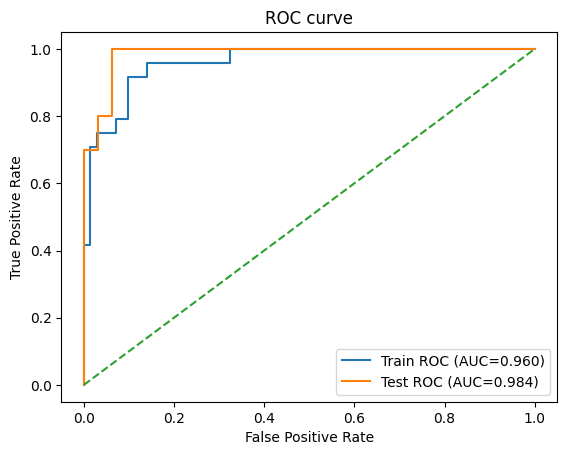

In [13]:
y_train_proba = pipe.predict_proba(X_train[significant_features])[:, 1]
y_test_proba = pipe.predict_proba(X_test[significant_features])[:, 1]

auc_train = roc_auc_score(y_train, y_train_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

print("\nROC-AUC TRAIN:", auc_train)
print("ROC-AUC TEST :", auc_test)

fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

plt.figure()
plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC={auc_train:.3f})")
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC={auc_test:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.show()

как мы и видели до этого, качество высокое и на трейн еи на тесте

In [14]:
coef = pipe.named_steps["lr"].coef_[0]
coef_df = pd.DataFrame({
    "feature": significant_features,
    "beta": coef,
    "odds_ratio": np.exp(coef),
}).sort_values("beta", ascending=False)

print("Интерпретация коэффициентов (sklearn)")
print(coef_df)

Интерпретация коэффициентов (sklearn)
                        feature      beta  odds_ratio
0         Logged GDP per capita  2.142235    8.518452
2                Social support  1.125237    3.080946
1  Freedom to make life choices  1.039202    2.826961


- Logged GDP per capita- самый сильный фактор: при увеличении показателя на 1 стандартное отклонение шансы попасть в топ-25% по счастью возрастают примерно в 8.5 раза.

- Social support- существенный положительный эффект: рост социальной поддержки увеличивает шансы высокого уровня счастья примерно в 3 раза.

- Freedom to make life choices- также значимый фактор: повышение свободы выбора увеличивает шансы примерно в 2.8 раза.

### Задание 3

Применяя данные из предыдущего пункта построить модель Случайного леса. Использовать разделение на обучающую и тестовую выборки. Аргументировать выбор количества деревьев и их глубины. Сравнить качество модели на обучении и тесте. Для оценки качества модели использовать метрики Accuracy, матрицу ошибок и ROC-кривую. Описать полученные результаты. Определить важность признаков, используя методы MDI, MDA и shap-value. Описать полученные результаты (2 балла).

подготовим данные

In [15]:
target_col = "Ladder score"
feature_cols = [
    "Logged GDP per capita",
    "Social support",
    "Healthy life expectancy",
    "Freedom to make life choices",
    "Perceptions of corruption",
    "Generosity",
]

X = df[feature_cols].copy()
q3 = df[target_col].quantile(0.75)
y = (df[target_col] > q3).astype(int)

print("Q3:", q3)
print("Доля класса 1:", y.mean())

Q3: 6.334
Доля класса 1: 0.24817518248175183


Разделение на обучающую и тестовую выборки

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (95, 6) Test size: (42, 6)


Выбор гиперпараметров сделаем с помощью grid search

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced", 
)

param_grid = {
    "n_estimators": [20, 50, 100, 300, 500],
    "max_depth": [None, 1, 2, 3, 4, 5, 8],
    "min_samples_leaf": [1, 2, 5, 7, 10],
}

grid = GridSearchCV(
    rf,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print("Лучшие параметры:", grid.best_params_)
print("Лучший CV ROC-AUC (train):", grid.best_score_)

Лучшие параметры: {'max_depth': 1, 'min_samples_leaf': 1, 'n_estimators': 100}
Лучший CV ROC-AUC (train): 0.9480952380952381


- как показал грид серч, лучшая модель- та, которая использует не деревья, а "пни", то есть max_depth = 1. 

- это напрямую указыват на то что классы хорошо разделимы

- min_samples_leaf = 1 тоже

- еще более высокий рок-аук: модель обобщает лучше

- в итоге, можео предположить что зависимости в данных почти линейны, и деревья лишь слегка улучшают качество

Сравнение качества на train и test: Accuracy и матрица ошибок

In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

print("Accuracy TRAIN:", acc_train)
print("Accuracy TEST :", acc_test)

cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

print("\nConfusion matrix TRAIN:\n", cm_train)
print("\nConfusion matrix TEST:\n", cm_test)

Accuracy TRAIN: 0.8736842105263158
Accuracy TEST : 0.9523809523809523

Confusion matrix TRAIN:
 [[61 10]
 [ 2 22]]

Confusion matrix TEST:
 [[30  2]
 [ 0 10]]


- качество на тестовой выборке еще лучше чем на обучении - модель хорошо справляется

- FN = 0- модель не пропускает страны с высоким уровнем счастья

- FP = 2- небольшое число ложных отнесений к высокому счастью.

- случайный лес достигает чуть более лучшего качества, улавливая нелинейные зависимости

ROC-AUC 

ROC-AUC TRAIN: 0.971537558685446
ROC-AUC TEST : 0.99375


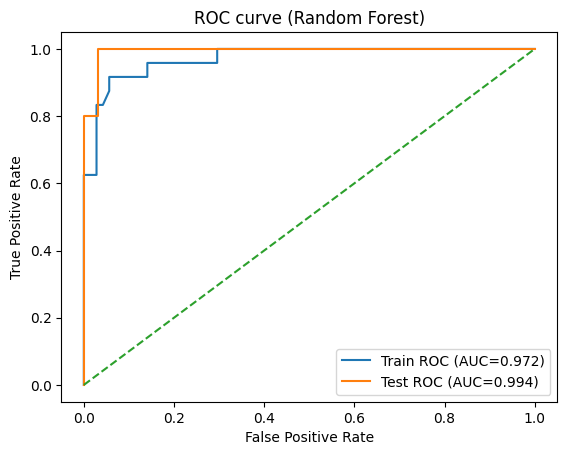

In [19]:
y_train_proba = best_rf.predict_proba(X_train)[:, 1]
y_test_proba = best_rf.predict_proba(X_test)[:, 1]

auc_train = roc_auc_score(y_train, y_train_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

print("ROC-AUC TRAIN:", auc_train)
print("ROC-AUC TEST :", auc_test)

fpr_tr, tpr_tr, _ = roc_curve(y_train, y_train_proba)
fpr_te, tpr_te, _ = roc_curve(y_test, y_test_proba)

plt.figure()
plt.plot(fpr_tr, tpr_tr, label=f"Train ROC (AUC={auc_train:.3f})")
plt.plot(fpr_te, tpr_te, label=f"Test ROC (AUC={auc_test:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve (Random Forest)")
plt.legend()
plt.show()

Важность признаков: MDI

MDI importance:
 Logged GDP per capita           0.35
Healthy life expectancy         0.21
Social support                  0.15
Perceptions of corruption       0.15
Freedom to make life choices    0.14
Generosity                      0.00
dtype: float64


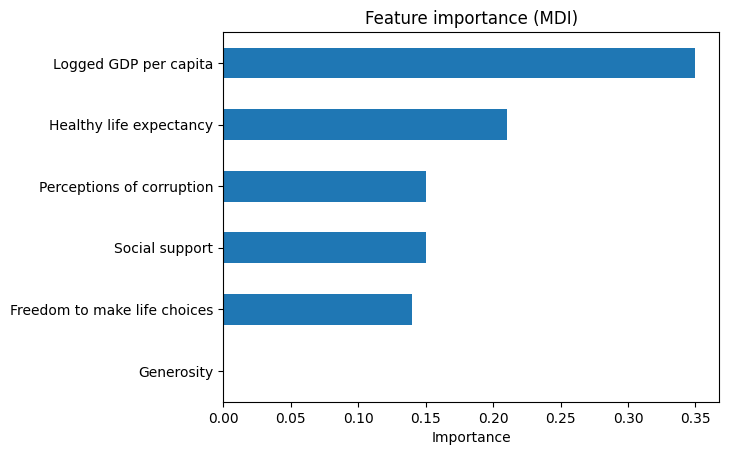

In [20]:
mdi = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("MDI importance:\n", mdi)

plt.figure()
mdi.sort_values().plot(kind="barh")
plt.title("Feature importance (MDI)")
plt.xlabel("Importance")
plt.show()

- Logged GDP per capita вносит наибольший вклад в разбиения деревьев. является ключевым для классификации стран по уровню счастья

- Generosity- минимальный вклад, практически не используется моделью

- остальные признаки- средний умеренный эффект.

- выводы сопоставимы с выводами, сделанными выше: случайный лес в первую очередь опирается на экономическое развитие, здоровье и социальную поддержку.

Важность признаков: MDA

MDA importance (mean drop in ROC-AUC):
 Logged GDP per capita           0.066667
Perceptions of corruption       0.026615
Healthy life expectancy         0.007083
Social support                  0.006042
Generosity                      0.000000
Freedom to make life choices   -0.003542
dtype: float64


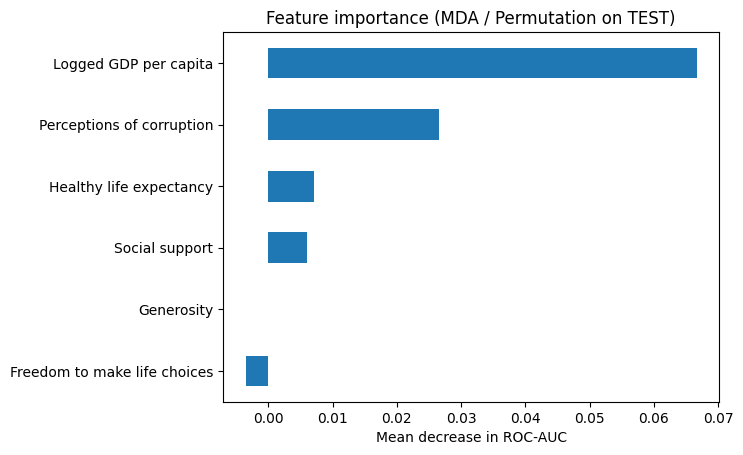

In [21]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_rf,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)

mda = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)
print("MDA importance (mean drop in ROC-AUC):\n", mda)

plt.figure()
mda.sort_values().plot(kind="barh")
plt.title("Feature importance (MDA / Permutation on TEST)")
plt.xlabel("Mean decrease in ROC-AUC")
plt.show()

- Perceptions of corruption чуть более значимый признак, чем Healthy life expectancy: в этом отличие от предыдущего резульатта

- признак Generosity не важен совсем.

Важность признаков: SHAP values

In [22]:
pip install shap



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


SHAP importance (mean |shap|):
 Logged GDP per capita           0.136014
Healthy life expectancy         0.066248
Social support                  0.053876
Freedom to make life choices    0.039986
Perceptions of corruption       0.038834
Generosity                      0.000000
dtype: float64


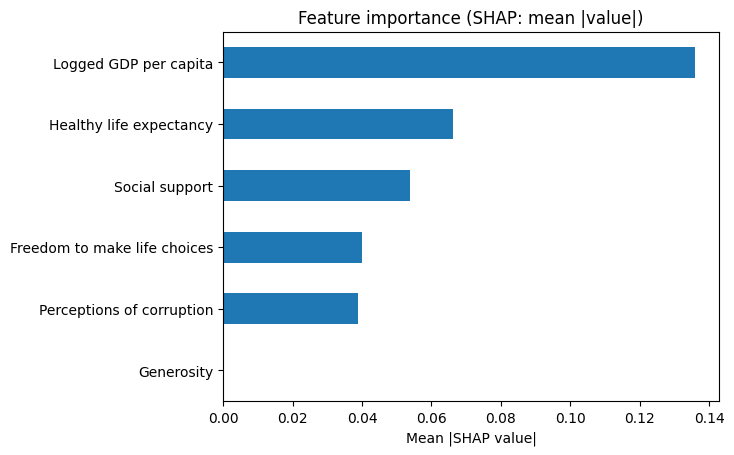

In [23]:
import shap

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values
    if sv.ndim == 3:
        sv = sv[:, :, 1]

sv = np.asarray(sv)

if sv.shape[0] != X_test.shape[0] and sv.shape[1] == X_test.shape[0]:
    sv = sv.T

shap_importance = pd.Series(
    np.mean(np.abs(sv), axis=0),
    index=feature_cols
).sort_values(ascending=False)

print("SHAP importance (mean |shap|):\n", shap_importance)

plt.figure()
shap_importance.sort_values().plot(kind="barh")
plt.title("Feature importance (SHAP: mean |value|)")
plt.xlabel("Mean |SHAP value|")
plt.show()

результаты сопоставимы с сделанными ранее

### Задание 4

Применяя алгоритм GBM решить задачу классификации. Оценить качество модели и важность признаков аналогично пункту 4. Описать полученные результаты (2 балла).  Сравнить три модели классификации (логистическая регрессия, случайный лес, GBM), выбрать оптимальную и аргументировать свой выбор (1 балл). Для сравнения метрик качества моделей использовать тестовые выборки, для сравнения интерпретационных способностей -важность признаков.

Выбор гиперпараметров GBM сделаем с помощью grid search

In [24]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

gbm = GradientBoostingClassifier(random_state=42)

param_grid = {
    "n_estimators": [50, 100, 200, 300],
    "learning_rate": [0.005, 0.01, 0.05, 0.1, 0.5, 0.75, 1],
    "max_depth": [3, 4, 6, 8],
}

grid_gbm = GridSearchCV(
    gbm,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_gbm.fit(X_train, y_train)

best_gbm = grid_gbm.best_estimator_

print("Лучшие параметры GBM:", grid_gbm.best_params_)
print("Лучший CV ROC-AUC (train):", grid_gbm.best_score_)

Лучшие параметры GBM: {'learning_rate': 0.5, 'max_depth': 3, 'n_estimators': 50}
Лучший CV ROC-AUC (train): 0.9195238095238094


- достаточно неглубоких деревьев - с глубиной 3

- n_estimators = 50- значит в самом бустинге деревьев не так много, достигается лучшее качество при 50 деревьях

- шаг обучения довольно высокий- 0.5 - значит модель быстрее сходится с таким шагом

- рок-аук все еще очень высокий, но чуть меньше чем показывали предыдущие модели

Оценка качества GBM: Accuracy и матрица ошибок

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_train_pred_gbm = best_gbm.predict(X_train)
y_test_pred_gbm = best_gbm.predict(X_test)

acc_train_gbm = accuracy_score(y_train, y_train_pred_gbm)
acc_test_gbm = accuracy_score(y_test, y_test_pred_gbm)

print("GBM Accuracy TRAIN:", acc_train_gbm)
print("GBM Accuracy TEST :", acc_test_gbm)

cm_train_gbm = confusion_matrix(y_train, y_train_pred_gbm)
cm_test_gbm = confusion_matrix(y_test, y_test_pred_gbm)

print("\nGBM Confusion matrix TRAIN:\n", cm_train_gbm)
print("\nGBM Confusion matrix TEST:\n", cm_test_gbm)

GBM Accuracy TRAIN: 1.0
GBM Accuracy TEST : 0.9523809523809523

GBM Confusion matrix TRAIN:
 [[71  0]
 [ 0 24]]

GBM Confusion matrix TEST:
 [[30  2]
 [ 0 10]]


- Accuracy чуть меньше на тесте, но всеравно оочень хорошее

- модель не пропускает страны с высоким уровнем счастья ,всего 2 ложных срабатывания на тесте.

- думаю, такое хорошее качество из-за маленького количества признаков

ROC-кривая и ROC-AUC для GBM

GBM ROC-AUC TRAIN: 1.0
GBM ROC-AUC TEST : 0.996875


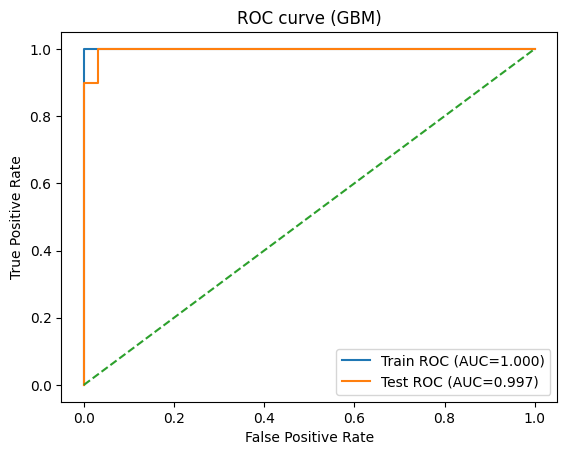

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_train_proba_gbm = best_gbm.predict_proba(X_train)[:, 1]
y_test_proba_gbm = best_gbm.predict_proba(X_test)[:, 1]

auc_train_gbm = roc_auc_score(y_train, y_train_proba_gbm)
auc_test_gbm = roc_auc_score(y_test, y_test_proba_gbm)

print("GBM ROC-AUC TRAIN:", auc_train_gbm)
print("GBM ROC-AUC TEST :", auc_test_gbm)

fpr_tr, tpr_tr, _ = roc_curve(y_train, y_train_proba_gbm)
fpr_te, tpr_te, _ = roc_curve(y_test, y_test_proba_gbm)

plt.figure()
plt.plot(fpr_tr, tpr_tr, label=f"Train ROC (AUC={auc_train_gbm:.3f})")
plt.plot(fpr_te, tpr_te, label=f"Test ROC (AUC={auc_test_gbm:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve (GBM)")
plt.legend()
plt.show()

Важность признаков GBM: MDI

GBM MDI importance:
 Logged GDP per capita           0.603812
Healthy life expectancy         0.130042
Social support                  0.086935
Generosity                      0.081385
Freedom to make life choices    0.052882
Perceptions of corruption       0.044942
dtype: float64


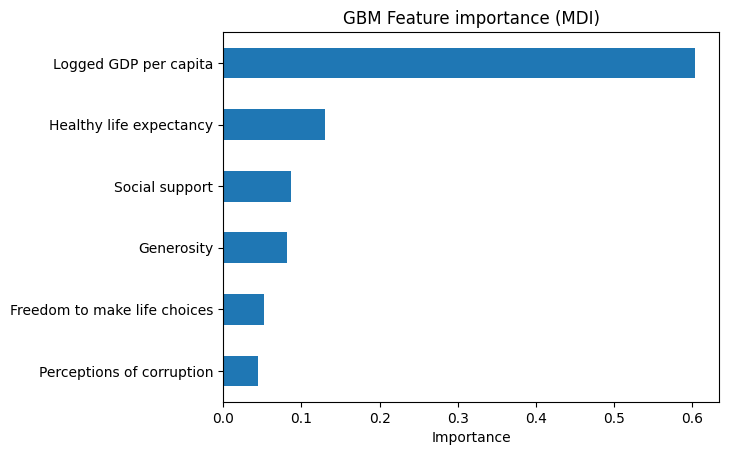

In [27]:
gbm_mdi = pd.Series(
    best_gbm.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("GBM MDI importance:\n", gbm_mdi)

plt.figure()
gbm_mdi.sort_values().plot(kind="barh")
plt.title("GBM Feature importance (MDI)")
plt.xlabel("Importance")
plt.show()

- Logged GDP per capita  все еще самый важный признак

- место самого маловлияющего фактора теперь знамает Perceptions of corruption - околонулевое влияние

- остальные признаки имеют влияние от 0,5 до 0,2

Важность признаков GBM: MDA

GBM MDA importance:
 Logged GDP per capita           0.119896
Social support                  0.052604
Perceptions of corruption       0.005104
Generosity                      0.004792
Healthy life expectancy         0.000937
Freedom to make life choices   -0.000729
dtype: float64


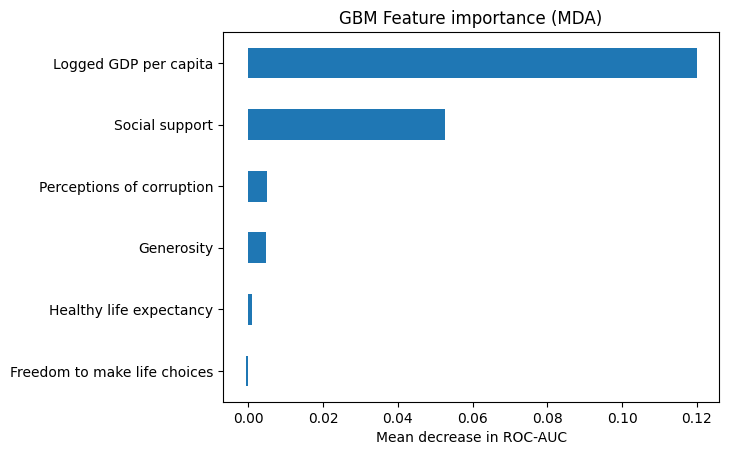

In [28]:
from sklearn.inspection import permutation_importance

perm_gbm = permutation_importance(
    best_gbm,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)

gbm_mda = pd.Series(
    perm_gbm.importances_mean,
    index=feature_cols
).sort_values(ascending=False)

print("GBM MDA importance:\n", gbm_mda)

plt.figure()
gbm_mda.sort_values().plot(kind="barh")
plt.title("GBM Feature importance (MDA)")
plt.xlabel("Mean decrease in ROC-AUC")
plt.show()

- интересный результат: Healthy life expectancy  теперь вообще неважный признак, даже немного отрицательный, хотя в других можелях он был значительным

- Freedom to make life choices теперь тоже невлияющий признак

- остальный примерно на тех же местах по значимости

- заметим, что в целом значения значимости уменьшились: теперь самое большое около 0.12

Важность признаков GBM: SHAP values

GBM SHAP importance:
 Logged GDP per capita           4.959630
Social support                  2.561438
Freedom to make life choices    1.473886
Perceptions of corruption       0.957185
Healthy life expectancy         0.811106
Generosity                      0.556381
dtype: float64


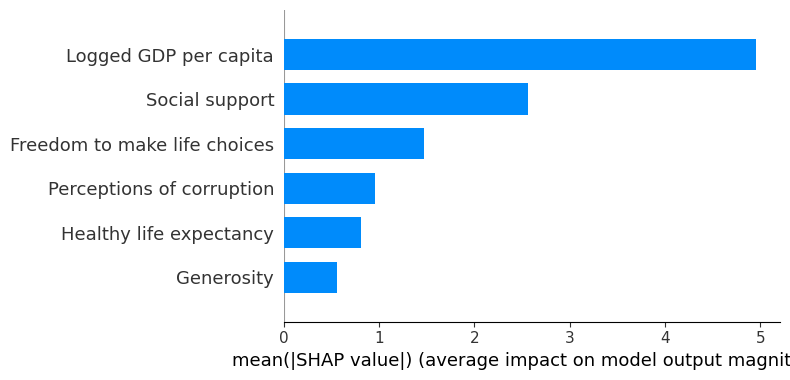

In [29]:
import shap

explainer_gbm = shap.TreeExplainer(best_gbm)
shap_values_gbm = explainer_gbm.shap_values(X_test)

if isinstance(shap_values_gbm, list):
    sv_gbm = shap_values_gbm[1]
else:
    sv_gbm = shap_values_gbm

shap_importance_gbm = pd.Series(
    np.mean(np.abs(sv_gbm), axis=0),
    index=feature_cols
).sort_values(ascending=False)

print("GBM SHAP importance:\n", shap_importance_gbm)

shap.summary_plot(sv_gbm, X_test, plot_type="bar")

результаты сопоставимы с предыдущими моделями

Сравнение трёх моделей по качеству

In [30]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "GBM"],
    "Accuracy (test)": [
        acc_test,        # из задания 2
        acc_test,        # RF из задания 3 (замени на своё имя переменной)
        acc_test_gbm
    ],
    "ROC-AUC (test)": [
        auc_test,        # логистическая регрессия
        auc_test,        # RF
        auc_test_gbm
    ],
})

comparison

,Model,Accuracy (test),ROC-AUC (test)
0,Logistic Regression,0.952381,0.993750
1,Random Forest,0.952381,0.993750
2,GBM,0.952381,0.996875


победитель- GBM	🥳🥳

(а вообще очень странно высокие результаты)

### Задание 5

Применяя алгоритм XGBoost решить задачу регрессии. Оценить важность признаков (основное внимание уделить gain и total gain). Описать полученные результаты (2 балла). Сравнить модель с моделью линейной регрессии: качество и интерпретационную способность. 

Цель: с помощью алгоритма XGBoost построить модель регрессии для прогнозирования уровня счастья (Ladder score), оценить важность признаков (с акцентом на gain и total gain) и сравнить модель с линейной регрессией по качеству и интерпретационным возможностям.

In [31]:
X = df[feature_cols].copy()
y_reg = df["Ladder score"].copy()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg,
    test_size=0.30,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (95, 6)
Test size : (42, 6)


Базовая модель: линейная регрессия

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_train_pred_lr = lr.predict(X_train)
y_test_pred_lr = lr.predict(X_test)

print("Linear Regression R2 TRAIN:", r2_score(y_train, y_train_pred_lr))
print("Linear Regression R2 TEST :", r2_score(y_test, y_test_pred_lr))

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))
print("Linear Regression RMSE TEST:", rmse_test)

Linear Regression R2 TRAIN: 0.82342674327866
Linear Regression R2 TEST : 0.8240595993500456
Linear Regression RMSE TEST: 0.47793987118705816


Модель XGBoost Regressor

In [33]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,feature_types,None


Качество XGBoost

In [34]:
y_train_pred_xgb = xgb.predict(X_train)
y_test_pred_xgb = xgb.predict(X_test)

print("XGBoost R2 TRAIN:", r2_score(y_train, y_train_pred_xgb))
print("XGBoost R2 TEST :", r2_score(y_test, y_test_pred_xgb))

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))
print("Linear Regression RMSE TEST:", rmse_test)

XGBoost R2 TRAIN: 0.9965736818574569
XGBoost R2 TEST : 0.795661851983245
Linear Regression RMSE TEST: 0.47793987118705816


Важность признаков в XGBoost: gain и total gain

In [35]:
import pandas as pd

booster = xgb.get_booster()
importance = booster.get_score(importance_type="gain")
total_gain = booster.get_score(importance_type="total_gain")

gain_df = pd.DataFrame({
    "feature": importance.keys(),
    "gain": importance.values(),
    "total_gain": [total_gain[f] for f in importance.keys()]
}).sort_values("total_gain", ascending=False)

gain_df

,feature,gain,total_gain
1,Social support,0.885487,278.042847
0,Logged GDP per capita,0.492015,169.253326
3,Freedom to make life choices,0.448087,106.644592
2,Healthy life expectancy,0.310686,104.390533
5,Generosity,0.100346,26.792381
4,Perceptions of corruption,0.086439,18.238701


выводы:

- XGBoost достигает почти идеального качества- 0.99

- чуть ухудшение на тесте до 0.8

- различие с линейной регрессией заметно: XGBoost явно лучше улавливает нелинейные зависимости, которые всеже присутствуют в данных. однако, как показало ухудшение качества на тесте, он менее устойчив. и менее интерпретируем. 

- по важности, доминирующие признаки те же, что и в прошлых моделях

### Задание 6

На основе алгоритмов APriori и FPG выделить 8 логичных ассоциативных правил и 4, противоречащих общей логики.  Описать полученные результаты (2 балла).

Подготовка данных для ассоциативного анализа

In [36]:
df_bin = df[feature_cols].copy()

for col in df_bin.columns:
    df_bin[col] = (df_bin[col] > df_bin[col].median()).astype(int)

df_bin.head()

,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Perceptions of corruption,Generosity
0,1,1,1,1,0,0
1,1,1,1,1,0,1
2,1,1,1,1,0,1
3,1,1,1,1,0,0
4,1,1,1,1,0,1


Алгоритм Apriori

In [37]:
from mlxtend.frequent_patterns import apriori, association_rules

freq_apriori = apriori(
    df_bin,
    min_support=0.3,
    use_colnames=True
)

rules_apriori = association_rules(
    freq_apriori,
    metric="confidence",
    min_threshold=0.6
)

rules_apriori = rules_apriori.sort_values(
    by="lift",
    ascending=False
)

rules_apriori

/Users/maria/Desktop/Code/.venv/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
13,(Logged GDP per capita),"(Social support, Healthy life expectancy)",0.496350,0.379562,0.350365,0.705882,1.859729,1.0,0.161969,2.109489,0.917874,0.666667,0.525952,0.814480
12,"(Social support, Healthy life expectancy)",(Logged GDP per capita),0.379562,0.496350,0.350365,0.923077,1.859729,1.0,0.161969,6.547445,0.745098,0.666667,0.847269,0.814480
15,(Healthy life expectancy),"(Logged GDP per capita, Social support)",0.496350,0.394161,0.350365,0.705882,1.790850,1.0,0.154723,2.059854,0.876812,0.648649,0.514529,0.797386
10,"(Logged GDP per capita, Social support)",(Healthy life expectancy),0.394161,0.496350,0.350365,0.888889,1.790850,1.0,0.154723,4.532847,0.728916,0.648649,0.779388,0.797386
11,"(Logged GDP per capita, Healthy life expectancy)",(Social support),0.416058,0.496350,0.350365,0.842105,1.696594,1.0,0.143854,3.189781,0.703125,0.623377,0.686499,0.773994
14,(Social support),"(Logged GDP per capita, Healthy life expectancy)",0.496350,0.416058,0.350365,0.705882,1.696594,1.0,0.143854,1.985401,0.815217,0.623377,0.496324,0.773994
2,(Logged GDP per capita),(Healthy life expectancy),0.496350,0.496350,0.416058,0.838235,1.688798,1.0,0.169695,3.113470,0.809814,0.721519,0.678815,0.838235
3,(Healthy life expectancy),(Logged GDP per capita),0.496350,0.496350,0.416058,0.838235,1.688798,1.0,0.169695,3.113470,0.809814,0.721519,0.678815,0.838235
0,(Logged GDP per capita),(Social support),0.496350,0.496350,0.394161,0.794118,1.599913,1.0,0.147797,2.446298,0.744498,0.658537,0.591219,0.794118
1,(Social support),(Logged GDP per capita),0.496350,0.496350,0.394161,0.794118,1.599913,1.0,0.147797,2.446298,0.744498,0.658537,0.591219,0.794118


алгоритм FP-Growth

In [38]:
from mlxtend.frequent_patterns import fpgrowth

freq_fp = fpgrowth(
    df_bin,
    min_support=0.3,
    use_colnames=True
)

rules_fp = association_rules(
    freq_fp,
    metric="confidence",
    min_threshold=0.6
)

rules_fp = rules_fp.sort_values(
    by="lift",
    ascending=False
)

rules_fp

/Users/maria/Desktop/Code/.venv/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
9,(Logged GDP per capita),"(Social support, Healthy life expectancy)",0.496350,0.379562,0.350365,0.705882,1.859729,1.0,0.161969,2.109489,0.917874,0.666667,0.525952,0.814480
8,"(Social support, Healthy life expectancy)",(Logged GDP per capita),0.379562,0.496350,0.350365,0.923077,1.859729,1.0,0.161969,6.547445,0.745098,0.666667,0.847269,0.814480
11,(Healthy life expectancy),"(Logged GDP per capita, Social support)",0.496350,0.394161,0.350365,0.705882,1.790850,1.0,0.154723,2.059854,0.876812,0.648649,0.514529,0.797386
6,"(Logged GDP per capita, Social support)",(Healthy life expectancy),0.394161,0.496350,0.350365,0.888889,1.790850,1.0,0.154723,4.532847,0.728916,0.648649,0.779388,0.797386
7,"(Logged GDP per capita, Healthy life expectancy)",(Social support),0.416058,0.496350,0.350365,0.842105,1.696594,1.0,0.143854,3.189781,0.703125,0.623377,0.686499,0.773994
10,(Social support),"(Logged GDP per capita, Healthy life expectancy)",0.496350,0.416058,0.350365,0.705882,1.696594,1.0,0.143854,1.985401,0.815217,0.623377,0.496324,0.773994
2,(Logged GDP per capita),(Healthy life expectancy),0.496350,0.496350,0.416058,0.838235,1.688798,1.0,0.169695,3.113470,0.809814,0.721519,0.678815,0.838235
3,(Healthy life expectancy),(Logged GDP per capita),0.496350,0.496350,0.416058,0.838235,1.688798,1.0,0.169695,3.113470,0.809814,0.721519,0.678815,0.838235
4,(Logged GDP per capita),(Social support),0.496350,0.496350,0.394161,0.794118,1.599913,1.0,0.147797,2.446298,0.744498,0.658537,0.591219,0.794118
5,(Social support),(Logged GDP per capita),0.496350,0.496350,0.394161,0.794118,1.599913,1.0,0.147797,2.446298,0.744498,0.658537,0.591219,0.794118


8 логичных правил:

1. Высокий ВВП => высокая социальная поддержка и высокая продолжительность жизни (lift = 1.86): экономически развитые страны, как правило, обладают развитой социальной инфраструктурой и лучшими условиями для здоровья населения.

2. социальная поддержка и здоровье => высокий ВВП (lift = 1.86, confidence = 0.92)

3. Высокая продолжительность жизни =>высокий ВВП (lift = 1.79):здоровье населения указывает на уровень развития страны.

4. Высокий ВВП и социальная поддержка => высокая продолжительность жизни (lift = 1.79): соц поддержка направлена так же и на поддержание здоровья людей

5. Высокий ВВП и здоровье => высокая социальная поддержка (lift = 1.70) в развитых странах соц поддержка тоже развита

6. Высокая свобода выбора => высокая социальная поддержка (lift = 1.41, confidence = 0.70): страны, имеющие высокую свободу принятия жизненных решений, характеризуются развитым социальным капиталом 

7. Высокий ВВП => высокая продолжительность жизни (lift = 1.69, confidence = 0.84): ожидаемая связь между доходами и состоянием здоровья.


правила, противоречащие общей логике

1. Высокая социальная поддержка и здоровье => высокий ВВП: кономически спорно трактовать социальные факторы как первопричину высокого дохода, а не как его следствие.

2. Высокая продолжительность жизни => высокий ВВП: в реальности рост ВВП, как правило, предшествует улучшению здоровья, а не наоборот.

3. Высокая социальная поддержка => высокий ВВП и здоровье: ассоциация корректна статистически, но причинно-следственная связь неочевидна

4. Высокая свобода выбора => высокий ВВП на душу населения (lift = 1.32, confidence = 0.66) В реальности экономическое благосостояние чаще является предпосылкой расширения свобод, а не их следствием. 